In [190]:
#importing libraries
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [191]:
#creting data frames
df1=pd.read_csv("Authentic-48k.csv")

In [192]:
df1.info

<bound method DataFrame.info of        articleID            domain                 date       category  \
0              1    jagonews24.com  2018-09-19 17:48:18      Education   
1              2    jagonews24.com  2018-09-19 17:48:19       National   
2              3    jagonews24.com  2018-09-19 17:48:20       National   
3              4    jagonews24.com  2018-09-19 17:48:21          Crime   
4              5    jagonews24.com  2018-09-19 17:48:21       National   
...          ...               ...                  ...            ...   
48673      61776  banglanews24.com  2018-10-11 16:39:23         Sports   
48674      61777  banglanews24.com  2018-10-11 16:39:27  International   
48675      61778  banglanews24.com  2018-10-11 16:39:30       Politics   
48676      61779  banglanews24.com  2018-10-11 16:39:32       National   
48677      61780  banglanews24.com  2018-10-11 16:39:36       National   

                                                headline  \
0       হট্টগোল করা

In [193]:
df2=pd.read_csv("LabeledAuthentic-7K.csv")

In [194]:
df2.info

<bound method DataFrame.info of       articleID                  domain                 date       category  \
0             1         bd-pratidin.com  2018-09-20 08:16:43         Sports   
1             2            jugantor.com  2018-09-20 20:20:20         Sports   
2             3            bd24live.com  2018-09-20 16:39:40       National   
3             4            bd24live.com  2018-09-19 18:27:56       National   
4             5            somoynews.tv  2018-09-20 10:15:28        Finance   
...         ...                     ...                  ...            ...   
7197       8263          jagonews24.com  2018-09-23 11:12:27       National   
7198       8265          jagonews24.com  2018-09-24 13:36:25       National   
7199       8266          jagonews24.com  2018-09-23 19:36:27       National   
7200       8267       independent24.com  2018-09-21 14:26:51       National   
7201       8268  bangla.thereport24.com  2018-09-23 12:29:50  Entertainment   

                   

In [195]:
Auth = [df1, df2]

In [196]:
#mergining data frames
df_auth = pd.concat(Auth)

In [197]:
# randomly picking 2598 rows
df_auth = df_auth.sample(n=2598, replace=True)

In [198]:
df_auth.value_counts("label")

label
1.0    2598
dtype: int64

In [199]:
df_auth['category'].value_counts()

National         1047
International     347
Sports            341
Editorial         179
Politics          145
Entertainment     144
Miscellaneous     109
Crime              66
Education          61
Finance            57
Technology         53
Lifestyle          49
Name: category, dtype: int64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'Crime'),
  Text(1, 0, 'Miscellaneous'),
  Text(2, 0, 'International'),
  Text(3, 0, 'Sports'),
  Text(4, 0, 'National'),
  Text(5, 0, 'Editorial'),
  Text(6, 0, 'Politics'),
  Text(7, 0, 'Entertainment'),
  Text(8, 0, 'Lifestyle'),
  Text(9, 0, 'Education'),
  Text(10, 0, 'Finance'),
  Text(11, 0, 'Technology')])

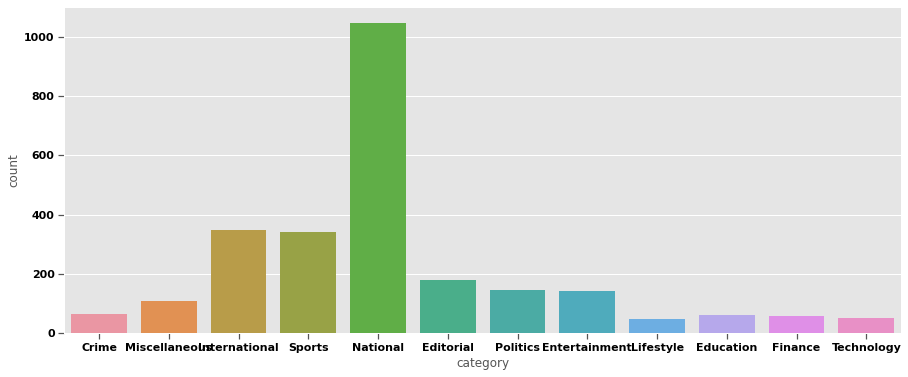

In [200]:
plt.figure(figsize=(15, 6))  # First Value fo X axis and Y value for Y axis
sns.countplot(x='category',data=df_auth)
plt.yticks(fontsize=11, color='black')
plt.xticks(fontsize=11, color='black')
#plt.set_xlabel('')

#  WordCloud for Authentic

In [201]:
type(df_auth['content'].tolist())

list

In [202]:
#Convert List to Text data
ta = ' '.join(df_auth['content'].tolist()) 

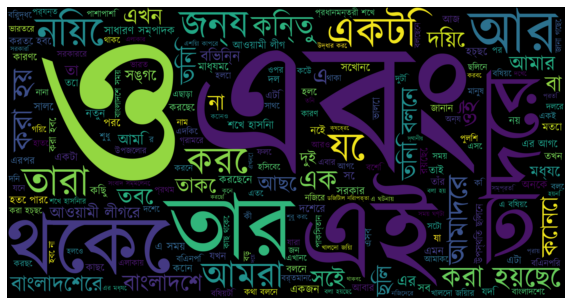

In [203]:
from bidi.algorithm import get_display
from wordcloud import WordCloud

bidi_text = get_display(ta)
rgx = r"[\u0980-\u09FF]+"
wordcloud = WordCloud(width=1920,height=1000,font_path='kalpurush.ttf',regexp=rgx).generate(bidi_text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [204]:
df3=pd.read_csv("Fake-1k.csv")

In [205]:
df3.info

<bound method DataFrame.info of       articleID                    domain                        date  \
0             1         channeldhaka.news   2019-03-14T13:34:14+00:00   
1             2                 earki.com            সেম্বর ১৭, ২০১৮    
2             3                 earki.com  ২০:৩৯, জানুয়ারি ১৪, ২০১৯    
3             4         channeldhaka.news   2018-06-30T15:56:47+00:00   
4             5  motikontho.wordpress.com   2013-03-05T21:55:45+00:00   
...         ...                       ...                         ...   
1294       1303           bengalbeats.com   2019-03-31T21:34:42+00:00   
1295       1304      bengaliviralnews.com   2018-01-16T15:36:12+00:00   
1296       1305         channeldhaka.news   2018-12-03T18:09:08+00:00   
1297       1306                 earki.com  ১৭:৩৬, জানুয়ারি ০৭, ২০১৯    
1298       1307         channeldhaka.news   2019-03-09T23:00:05+00:00   

           category                                           headline  \
0     Internation

In [206]:
df4=pd.read_csv("LabeledFake-1K.csv")

In [207]:
df4.info

<bound method DataFrame.info of       articleID                    domain                        date  \
0             1         channeldhaka.news   2019-03-14T13:34:14+00:00   
1             2                 earki.com            সেম্বর ১৭, ২০১৮    
2             3                 earki.com  ২০:৩৯, জানুয়ারি ১৪, ২০১৯    
3             4         channeldhaka.news   2018-06-30T15:56:47+00:00   
4             5  motikontho.wordpress.com   2013-03-05T21:55:45+00:00   
...         ...                       ...                         ...   
1294       1303           bengalbeats.com   2019-03-31T21:34:42+00:00   
1295       1304      bengaliviralnews.com   2018-01-16T15:36:12+00:00   
1296       1305         channeldhaka.news   2018-12-03T18:09:08+00:00   
1297       1306                 earki.com  ১৭:৩৬, জানুয়ারি ০৭, ২০১৯    
1298       1307         channeldhaka.news   2019-03-09T23:00:05+00:00   

           category                         source   relation  \
0     International       

In [208]:
Fake = [df3, df4]

In [209]:
#mergining data frames
df_fake = pd.concat(Fake)

In [210]:
df_fake.value_counts("label")

label
0    2598
dtype: int64

In [211]:
df_fake['category'].value_counts()

Miscellaneous    1308
Entertainment     212
Lifestyle         204
National          198
International     182
Politics          180
Sports            108
Crime              84
Education          60
Technology         58
Finance             4
Name: category, dtype: int64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'International'),
  Text(1, 0, 'Miscellaneous'),
  Text(2, 0, 'Sports'),
  Text(3, 0, 'Lifestyle'),
  Text(4, 0, 'Politics'),
  Text(5, 0, 'Technology'),
  Text(6, 0, 'National'),
  Text(7, 0, 'Entertainment'),
  Text(8, 0, 'Crime'),
  Text(9, 0, 'Education'),
  Text(10, 0, 'Finance')])

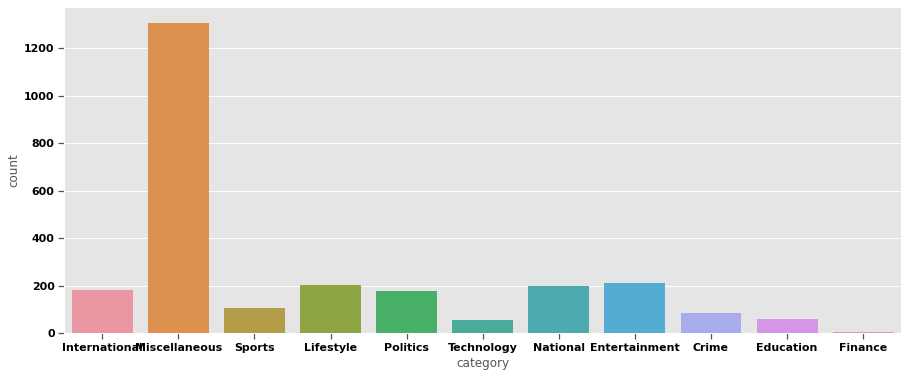

In [212]:
plt.figure(figsize=(15, 6))  # First Value fo X axis and Y value for Y axis
sns.countplot(x='category',data=df_fake)
plt.yticks(fontsize=11, color='black')
plt.xticks(fontsize=11, color='black')

# # WordCloud for Fake

In [213]:
type(df_fake['content'].tolist())

list

In [214]:
#Convert List to Text data
tf = ' '.join(df_fake['content'].tolist()) 

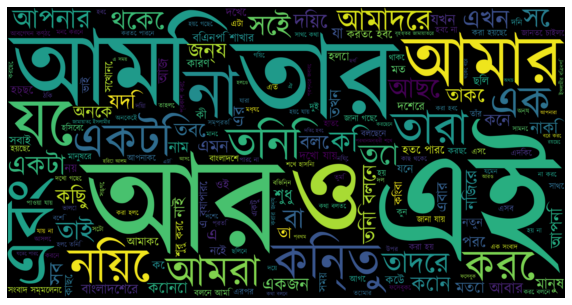

In [215]:
from bidi.algorithm import get_display
from wordcloud import WordCloud

bidi_text = get_display(tf)
rgx = r"[\u0980-\u09FF]+"
wordcloud = WordCloud(width=1920,height=1000,font_path='kalpurush.ttf',regexp=rgx).generate(bidi_text)
fig = plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [216]:
frame = [df_auth, df_fake]

In [217]:
#mergining data frames
df = pd.concat(frame)

df['space'] = " "
df['news'] = df['headline'] + df['space'] + df['content']

In [218]:
df.value_counts("label")

label
0.0    2598
1.0    2598
dtype: int64

In [219]:
df.info

<bound method DataFrame.info of        articleID                  domain                        date  \
1873        1939        dhakatimes24.com         2018-09-19 19:11:45   
45696      58126  bangla.thereport24.com         2018-10-11 12:52:03   
4783        5858         kalerkantho.com         2018-09-21 14:13:57   
28407      36044          prothomalo.com         2018-10-02 15:12:57   
2940        3116      channelionline.com         2018-09-20 13:13:44   
...          ...                     ...                         ...   
1294        1303         bengalbeats.com   2019-03-31T21:34:42+00:00   
1295        1304    bengaliviralnews.com   2018-01-16T15:36:12+00:00   
1296        1305       channeldhaka.news   2018-12-03T18:09:08+00:00   
1297        1306               earki.com  ১৭:৩৬, জানুয়ারি ০৭, ২০১৯    
1298        1307       channeldhaka.news   2019-03-09T23:00:05+00:00   

            category                                           headline  \
1873           Crime        

In [220]:
df.head

<bound method NDFrame.head of        articleID                  domain                        date  \
1873        1939        dhakatimes24.com         2018-09-19 19:11:45   
45696      58126  bangla.thereport24.com         2018-10-11 12:52:03   
4783        5858         kalerkantho.com         2018-09-21 14:13:57   
28407      36044          prothomalo.com         2018-10-02 15:12:57   
2940        3116      channelionline.com         2018-09-20 13:13:44   
...          ...                     ...                         ...   
1294        1303         bengalbeats.com   2019-03-31T21:34:42+00:00   
1295        1304    bengaliviralnews.com   2018-01-16T15:36:12+00:00   
1296        1305       channeldhaka.news   2018-12-03T18:09:08+00:00   
1297        1306               earki.com  ১৭:৩৬, জানুয়ারি ০৭, ২০১৯    
1298        1307       channeldhaka.news   2019-03-09T23:00:05+00:00   

            category                                           headline  \
1873           Crime          

In [221]:
df.dtypes

articleID      int64
domain        object
date          object
category      object
headline      object
content       object
label        float64
source        object
relation      object
F-type        object
space         object
news          object
dtype: object

In [222]:
#chaning data frames type
df['content'] = df['content'].astype('string')
df['label'] = df['label'].astype('int64')

In [223]:
df.dtypes

articleID     int64
domain       object
date         object
category     object
headline     object
content      string
label         int64
source       object
relation     object
F-type       object
space        object
news         object
dtype: object

In [224]:
df.groupby("label").describe()

articleID                                                               \
          count          mean           std  min      25%      50%       75%   
label                                                                          
0        2598.0    653.268668    377.032471  1.0   326.25    653.0    978.75   
1        2598.0  27701.411085  19037.255805  2.0  8476.75  27191.0  44113.00   

                
           max  
label           
0       1307.0  
1      61774.0

In [225]:
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer() # object for making class-labels into binary numbers

In [226]:
df.columns

Index(['articleID', 'domain', 'date', 'category', 'headline', 'content',
       'label', 'source', 'relation', 'F-type', 'space', 'news'],
      dtype='object')

In [227]:
df.head

<bound method NDFrame.head of        articleID                  domain                        date  \
1873        1939        dhakatimes24.com         2018-09-19 19:11:45   
45696      58126  bangla.thereport24.com         2018-10-11 12:52:03   
4783        5858         kalerkantho.com         2018-09-21 14:13:57   
28407      36044          prothomalo.com         2018-10-02 15:12:57   
2940        3116      channelionline.com         2018-09-20 13:13:44   
...          ...                     ...                         ...   
1294        1303         bengalbeats.com   2019-03-31T21:34:42+00:00   
1295        1304    bengaliviralnews.com   2018-01-16T15:36:12+00:00   
1296        1305       channeldhaka.news   2018-12-03T18:09:08+00:00   
1297        1306               earki.com  ১৭:৩৬, জানুয়ারি ০৭, ২০১৯    
1298        1307       channeldhaka.news   2019-03-09T23:00:05+00:00   

            category                                           headline  \
1873           Crime          

In [228]:
df

,articleID,domain,date,category,headline,content,label,source,relation,F-type,space,news
1873,1939,dhakatimes24.com,2018-09-19 19:11:45,Crime,পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড,প্রায় ২৫ বছর আগে ঢাকার কেরানীগঞ্জে বাবা-ছেলে হ...,1,আদালত,Related,NaN,,পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড প্রায় ২...
45696,58126,bangla.thereport24.com,2018-10-11 12:52:03,Crime,"আদালতে বিচারক, যেকোনো সময় গ্রেনেড হামলার রায়",দ্য রিপোর্ট প্রতিবেদক : পুরান ঢাকার নাজিমুদ্দি...,1,NaN,NaN,NaN,,"আদালতে বিচারক, যেকোনো সময় গ্রেনেড হামলার রায় দ..."
4783,5858,kalerkantho.com,2018-09-21 14:13:57,Miscellaneous,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন ভারতের কের...,1,NaN,NaN,NaN,,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি ঔষধি গ...
28407,36044,prothomalo.com,2018-10-02 15:12:57,International,দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু,উত্তর ও দক্ষিণ কোরিয়ার সীমান্ত এলাকা থেকে স্থল...,1,NaN,NaN,NaN,,দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু উত্তর ও দ...
2940,3116,channelionline.com,2018-09-20 13:13:44,Sports,জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড,চ্যাম্পিয়ন্স লিগে নতুন মৌসুমের প্রথম রাতে হ্যা...,1,Not Found,Related,NaN,,জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড চ্যাম...
...,...,...,...,...,...,...,...,...,...,...,...,...
1294,1303,bengalbeats.com,2019-03-31T21:34:42+00:00,Miscellaneous,রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...,রাজশাহীর সাহেব বাজার মোড়ে রাতে ঘুমের মধ্যে হাস...,0,Reporter,Unrelated,Satire,,রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...
1295,1304,bengaliviralnews.com,2018-01-16T15:36:12+00:00,Miscellaneous,IAS ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদে...,IAS পরীক্ষায় এমন এমন অবাক করে দেওয়া প্রশ্ন এসে...,0,Reporter,Unrelated,Clickbaits,,IAS ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদে...
1296,1305,channeldhaka.news,2018-12-03T18:09:08+00:00,Crime,শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু!,শাওমি মোবাইল ফোন বিস্ফোরণ হয়ে স্বপ্নীল মজুমদা...,0,ফেনী ফায়ার স্টেশনের ইনচার্জ,Unrelated,Satire,,শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু! শাও...
1297,1306,earki.com,"১৭:৩৬, জানুয়ারি ০৭, ২০১৯",Miscellaneous,ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...,আপনাকে নতুন মন্ত্রিসভার সদস্যদের অভিনন্দন জানা...,0,Reporter,Related,Satire,,ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...


In [229]:
df.isnull()

,articleID,domain,date,category,headline,content,label,source,relation,F-type,space,news
1873,False,False,False,False,False,False,False,False,False,True,False,False
45696,False,False,False,False,False,False,False,True,True,True,False,False
4783,False,False,False,False,False,False,False,True,True,True,False,False
28407,False,False,False,False,False,False,False,True,True,True,False,False
2940,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1294,False,False,False,False,False,False,False,False,False,False,False,False
1295,False,False,False,False,False,False,False,False,False,False,False,False
1296,False,False,False,False,False,False,False,False,False,False,False,False
1297,False,False,False,False,False,False,False,False,False,False,False,False


In [230]:
df.value_counts("label")

label
0    2598
1    2598
dtype: int64

In [231]:
df

,articleID,domain,date,category,headline,content,label,source,relation,F-type,space,news
1873,1939,dhakatimes24.com,2018-09-19 19:11:45,Crime,পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড,প্রায় ২৫ বছর আগে ঢাকার কেরানীগঞ্জে বাবা-ছেলে হ...,1,আদালত,Related,NaN,,পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড প্রায় ২...
45696,58126,bangla.thereport24.com,2018-10-11 12:52:03,Crime,"আদালতে বিচারক, যেকোনো সময় গ্রেনেড হামলার রায়",দ্য রিপোর্ট প্রতিবেদক : পুরান ঢাকার নাজিমুদ্দি...,1,NaN,NaN,NaN,,"আদালতে বিচারক, যেকোনো সময় গ্রেনেড হামলার রায় দ..."
4783,5858,kalerkantho.com,2018-09-21 14:13:57,Miscellaneous,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন ভারতের কের...,1,NaN,NaN,NaN,,ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি ঔষধি গ...
28407,36044,prothomalo.com,2018-10-02 15:12:57,International,দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু,উত্তর ও দক্ষিণ কোরিয়ার সীমান্ত এলাকা থেকে স্থল...,1,NaN,NaN,NaN,,দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু উত্তর ও দ...
2940,3116,channelionline.com,2018-09-20 13:13:44,Sports,জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড,চ্যাম্পিয়ন্স লিগে নতুন মৌসুমের প্রথম রাতে হ্যা...,1,Not Found,Related,NaN,,জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড চ্যাম...
...,...,...,...,...,...,...,...,...,...,...,...,...
1294,1303,bengalbeats.com,2019-03-31T21:34:42+00:00,Miscellaneous,রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...,রাজশাহীর সাহেব বাজার মোড়ে রাতে ঘুমের মধ্যে হাস...,0,Reporter,Unrelated,Satire,,রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...
1295,1304,bengaliviralnews.com,2018-01-16T15:36:12+00:00,Miscellaneous,IAS ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদে...,IAS পরীক্ষায় এমন এমন অবাক করে দেওয়া প্রশ্ন এসে...,0,Reporter,Unrelated,Clickbaits,,IAS ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদে...
1296,1305,channeldhaka.news,2018-12-03T18:09:08+00:00,Crime,শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু!,শাওমি মোবাইল ফোন বিস্ফোরণ হয়ে স্বপ্নীল মজুমদা...,0,ফেনী ফায়ার স্টেশনের ইনচার্জ,Unrelated,Satire,,শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু! শাও...
1297,1306,earki.com,"১৭:৩৬, জানুয়ারি ০৭, ২০১৯",Miscellaneous,ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...,আপনাকে নতুন মন্ত্রিসভার সদস্যদের অভিনন্দন জানা...,0,Reporter,Related,Satire,,ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...


In [232]:
text = df['news'].values.tolist()

In [233]:
df.groupby("label").describe()

articleID                                                               \
          count          mean           std  min      25%      50%       75%   
label                                                                          
0        2598.0    653.268668    377.032471  1.0   326.25    653.0    978.75   
1        2598.0  27701.411085  19037.255805  2.0  8476.75  27191.0  44113.00   

                
           max  
label           
0       1307.0  
1      61774.0

In [234]:
df["label"].value_counts()

1    2598
0    2598
Name: label, dtype: int64

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


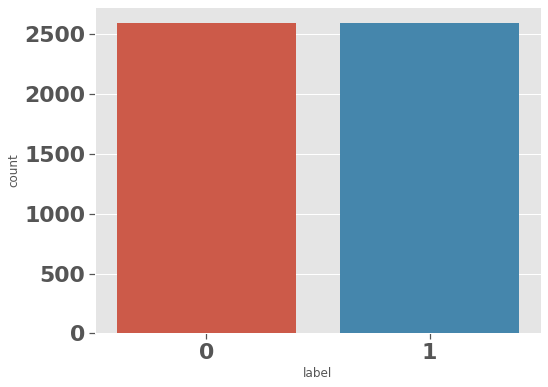

In [235]:
plt.subplots(figsize=(8,6))
sns.countplot(df["label"])
plt.show()

In [236]:
df['news'].info

<bound method Series.info of 1873     পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড প্রায় ২...
45696    আদালতে বিচারক, যেকোনো সময় গ্রেনেড হামলার রায় দ...
4783     ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি ঔষধি গ...
28407    দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু উত্তর ও দ...
2940     জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড চ্যাম...
                               ...                        
1294     রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...
1295     IAS ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদে...
1296     শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু! শাও...
1297     ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...
1298     মাঝ আকাশে পর্ন দেখার অভিযোগে পাইলট আটক! বিমান ...
Name: news, Length: 5196, dtype: object>

In [237]:
longest_string = max(df["news"], key=len)
print(len(longest_string))

22572


# Data Preprocessing

In [238]:
#importing libraries for data cleaning
import nltk
from bs4 import BeautifulSoup
import re,string,unicodedata

In [239]:
#Removing the html strips
def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

#Removing the square brackets
def remove_between_square_brackets(text):
    return re.sub('\[[^]]*\]', '', text)

#Removing the noisy text
def denoise_text(text):
    text = strip_html(text)
    text = remove_between_square_brackets(text)
    return text
#Apply function on description column
df['news']=df['news'].apply(denoise_text)

C:\Users\Asus\anaconda3\lib\site-packages\bs4\__init__.py:435: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  warnings.warn(


In [240]:
#remove special character
def rem_special_characters(text):
    pattern = re.compile('[!@#$%^&*()_+-={}\[\];:\'\"\|<>,.///?`~।]', flags=re.I)
    return pattern.sub(r'', text)
#remove non bangla character
def rem_non_bangla_characters(text):
    pattern = re.compile('[A-Z]', flags=re.I)
    return pattern.sub(r'', text)
#remove non empticons character
def rem_emoticons(text):
    regrex_pattern = re.compile(pattern = "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           "]+", flags = re.UNICODE)
    return regrex_pattern.sub(r'',text)

#remove noise
def Remove_text(text):
    text = rem_special_characters(text)
    text = rem_non_bangla_characters(text)
    text = rem_emoticons(text)
    return text
#Apply function on description column
df['news']=df['news'].apply(Remove_text)

In [241]:
df['news']

1873     পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড প্রায় ২...
45696    আদালতে বিচারক যেকোনো সময় গ্রেনেড হামলার রায় দ্...
4783     ঔষধি গাছ দিয়ে ৫০০ রোগ সারাতে পারেন যিনি ঔষধি গ...
28407    দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু উত্তর ও দ...
2940     জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড চ্যাম...
                               ...                        
1294     রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের মধ্যেই স...
1295      ইন্টারভিউ এ মেয়েটিকে জিজ্ঞসা করা হল মেয়েদের ক...
1296     শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু শাওম...
1297     ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...
1298     মাঝ আকাশে পর্ন দেখার অভিযোগে পাইলট আটক বিমান য...
Name: news, Length: 5196, dtype: object

In [242]:
#checking longest sting size
longest_string = max(df["news"], key=len)
print(len(longest_string))

21998


In [243]:
df.label[df.label == 1]="real"
df.label[df.label == 0]="fake"

C:\Users\Asus\AppData\Local\Temp\ipykernel_14124\3308837054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.label[df.label == 1]="real"


In [244]:
df['label']

1873     real
45696    real
4783     real
28407    real
2940     real
         ... 
1294     fake
1295     fake
1296     fake
1297     fake
1298     fake
Name: label, Length: 5196, dtype: object

In [245]:
from sklearn.preprocessing import LabelEncoder

lb_make = LabelEncoder()
df["Text_label"] = lb_make.fit_transform(df["label"])
df[["label", "Text_label"]].head(11)

,label,Text_label
1873,real,1
45696,real,1
4783,real,1
28407,real,1
2940,real,1
25261,real,1
6775,real,1
43139,real,1
31411,real,1
15374,real,1


In [246]:
df["label"].value_counts()

real    2598
fake    2598
Name: label, dtype: int64

In [247]:
longest_string = max(df["news"], key=len)
print(len(longest_string))

21998


In [248]:
#fuction for tokenizing text
def tokenized_data(sent):
    tokenized_text = sent.split()
    return tokenized_text

In [249]:
stop_words = { "অবশ্য" ,"অনেক","অনেকে","অনেকেই","অন্তত","অথবা","অথচ","অর্থাত","অন্য","আজ","আছে","আপনার","আপনি","আবার","আমরা"
"আমাকে","আমাদের","আমার","আমি","আরও","আর","আগে","আগেই","আই","অতএব","আগামী","অবধি","অনুযায়ী","আদ্যভাগে","এই","একই","একে",
"একটি","এখন","এখনও","এখানে","এখানেই","এটি","এটা","এটাই","এতটাই","এবং","একবার","এবার","এদের","এঁদের","এমন","এমনকী","এল",
"এর","এরা","এঁরা","এস","এত","এতে","এসে","একে","এ","ঐ","ই","ইহা","ইত্যাদি","উনি","উপর","উপরে","উচিত","ও","ওই","ওর","ওরা","ওঁর","ওঁরা",
"ওকে","ওদের","ওঁদের","ওখানে",'কত',"কবে",'করতে',"কয়েক""কয়েকটি","করবে","করলেন","করার","কারও","করা","করি","করিয়ে","করার",
"করাই","করলে","করলেন","করিতে","করিয়া","করেছিলেন","করছে","করছেন","করেছেন","করেছে","করেন","করবেন","করায়","করে","করেই",
"কাছ","কাছে","কাজে","কারণ","কিছু","কিছুই","কিন্তু","কিংবা","কি","কী","কেউ","কেউই","কাউকে","কেন","কে","কোনও","কোনো","কোন",
"কখনও","ক্ষেত্রে","খুব","গুলি","গিয়ে","গিয়েছে","গেছে","গেল","গেলে","গোটা","চলে","ছাড়া","ছাড়াও","ছিলেন","ছিল","জন্য","জানা","ঠিক","তিনি",
"তিনঐ","তিনিও","তখন","তবে","তবু","তাঁদের","তাঁাহারা","তাঁরা","তাঁর","তাঁকে","তাই","তেমন","তাকে","তাহা","তাহাতে","তাহার","তাদের","তারপর",
"তারা","তারৈ","তার","তাহলে","তিনি","তা","তাও","তাতে","তো","তত","তুমি","তোমার","তথা","থাকে","থাকা","থাকায়","থেকে","থেকেও","থাকবে",
"থাকেন","থাকবেন","থেকেই","দিকে","দিতে","দিয়ে","দিয়েছে","দিয়েছেন","দিলেন","দু","দুটি","দুটো","দেয়","দেওয়া","দেওয়ার","দেখা","দেখে","দেখতে",
"দ্বারা","ধরে","ধরা","নয়","নানা","না","নাকি","নাগাদ","নিতে","নিজে","নিজেই","নিজের","নিজেদের","নিয়ে","নেওয়া","নেওয়ার","নেই","নাই","পক্ষে",
"পর্যন্ত","পাওয়া","পারেন","পারি","পারে","পরে","পরেই","পরেও","পর","পেয়ে","প্রতি","প্রভৃতি","প্রায়","ফের","ফলে","ফিরে","ব্যবহার","বলতে",
"বললেন","বলেছেন","বলল","বলা","বলেন","বলে","বহু","বসে","বার","বা","বিনা","বরং","বদলে","বাদে","বার","বিশেষ","বিভিন্ন","বিষয়টি","ব্যবহার","ব্যাপারে""ভাবে","ভাবেই","মধ্যে","মধ্যেই",
"মধ্যেও","মধ্যভাগে","মাধ্যমে","মাত্র","মতো","মতোই","মোটেই","যখন","যদি","যদিও","যাবে","যায়","যাকে","যাওয়া","যাওয়ার","যত","যতটা","যা","যার",
"যারা","যাঁর","যাঁরা","যাদের","যান","যাচ্ছে","যেতে","যাতে","যেন","যেমন","যেখানে","যিনি","যে","রেখে","রাখা","রয়েছে","রকম","শুধু","সঙ্গে",
"সঙ্গেও","সমস্ত","সব","সবার","সহ","সুতরাং","সহিত","সেই","সেটা","সেটি","সেটাই","সেটাও","সম্প্রতি","সেখান","সেখানে","সে","স্পষ্ট","স্বয়ং","হইতে",
"হইবে","হৈলে","হইয়া","হচ্ছে","হত","হতে","হতেই","হবে","হবেন","হয়েছিল","হয়েছে","হয়েছেন","হয়ে","হয়নি","হয়","হয়েই","হয়তো","হল","হলে",
"হলেই","হলেও","হলো","হিসাবে","হওয়া","হওয়ার","হওয়ায়","হন","হোক","জন","জনকে","জনের","জানতে","জানায়","জানিয়ে","জানানো","জানিয়েছে",
"জন্য","জন্যওজে","জে","বেশ","দেন","তুলে","ছিলেন","চান","চায়","চেয়ে","মোট","যথেষ্ট","টি"}

In [250]:
def remove_stop_words(text):
    text = [w for w in text if not w in stop_words]
    text = ' '.join(text)
    return text

In [251]:
df['news'] = [remove_stop_words(tokenized_data(sent)) for sent in df['news'].tolist()]

In [252]:
longest_string = max(df["news"], key=len)
print(len(longest_string))

17380


In [253]:
df["news"]

1873     পুনঃবিচারেও পাঁচ আসামি ডাবল মৃত্যুদণ্ড ২৫ বছর ...
45696    আদালতে বিচারক যেকোনো সময় গ্রেনেড হামলার রায় দ্...
4783     ঔষধি গাছ ৫০০ রোগ সারাতে ঔষধি গাছ দিয়ে ৫০০ রোগ...
28407    দুই কোরিয়ার সীমান্তে মাইন সরানো শুরু উত্তর দক্...
2940     জুভেন্টাসের জয়ের দিনে রোনালদোর লাল কার্ড চ্যাম...
                               ...                        
1294     রাজশাহীতে স্বামীর হাঁচির আওয়াজে ঘুমের স্ত্রী হ...
1295     ইন্টারভিউ মেয়েটিকে জিজ্ঞসা মেয়েদের অঙ্গ বেশী ম...
1296     শাওমি মোবাইল বিস্ফোরণে কলেজছাত্রের মৃত্যু শাওম...
1297     ফেসবুকে যেভাবে নতুন মন্ত্রীদের অভিনন্দন বার্তা...
1298     মাঝ আকাশে পর্ন দেখার অভিযোগে পাইলট আটক বিমান আ...
Name: news, Length: 5196, dtype: object

In [254]:
#BNLTK
from bnltk.stemmer import BanglaStemmer

bn_stemmer = BanglaStemmer()
i = 0
strl = ' '
final_string = []
s = ''
for sent in df['news'].values:
    filtered_sentence = []
    for w in sent.split():
            s = bn_stemmer.stem(w)
            filtered_sentence.append(s)


    str1 = " ".join(filtered_sentence)
    final_string.append(str1)
    i+=1
    
df['cleaned'] = final_string

In [255]:
longest_string = max(df["cleaned"], key=len)
print(len(longest_string))

15847


In [256]:
text = df["cleaned"]

In [257]:
text


1873     পুনঃবিচারে পাঁচ আসামি ডাবল মৃত্যুদণ্ড ২৫ বছর ঢ...
45696    আদাল বিচারক যেকোনো সম গ্রেনেড হামল রা দ্য রিপো...
4783     ঔষধি গাছ ৫০০ রোগ সারা ঔষধি গাছ দিয় ৫০০ রোগ সা...
28407    দু কোরিয় সীমান্ মাইন সরানো শুরু উত্তর দক্ষিণ ক...
2940     জুভেন্টাস জয় দিন রোনালদোর লাল কার্ড চ্যাম্পিয়ন...
                               ...                        
1294     রাজশাহী স্বামীর হাঁচির আওয়াজ ঘুম স্ত্রী হার্ট ...
1295     ইন্টারভিউ মেয়েটি জিজ্ঞসা মেয়ে অঙ্গ বেশী মেয়ে উ...
1296     শাওমি মোবাইল বিস্ফোরণ কলেজছাত্র মৃত্যু শাওমি ম...
1297     ফেসবু যেভাব নতুন মন্ত্রী অভিনন্দন বার্তা জানা ...
1298     মাঝ আকাশ পর্ন দেখ অভিযোগ পাইলট আটক বিমান আকাশ ...
Name: cleaned, Length: 5196, dtype: object

In [258]:
import sklearn
vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(lowercase=False)
train_tfidf = vectorizer.fit_transform(text) # converting transformed vectors into tf-idf vectors
train_tfidf.shape #vector shape

(5196, 10577)

In [259]:
#vectorizer.get_feature_names()

In [260]:
#df = pd.DataFrame(train_tfidf.toarray(), columns = vectorizer.get_feature_names())
#print(df)

In [261]:
#train test split
from sklearn.model_selection import train_test_split

In [262]:
X_train, X_test, y_train, y_test = train_test_split(train_tfidf, df['Text_label'],stratify=df['Text_label'], test_size=0.3, random_state=42)

Y_pre = df['label']
target_names = list(set(Y_pre))

In [263]:
Y_pre.value_counts()

real    2598
fake    2598
Name: label, dtype: int64

In [264]:
target_names

['real', 'fake']

In [265]:
X_train

<3637x10577 sparse matrix of type '<class 'numpy.float64'>'
	with 278928 stored elements in Compressed Sparse Row format>

In [266]:
y_train.value_counts()

1    1819
0    1818
Name: Text_label, dtype: int64

In [267]:
y_test.value_counts()

0    780
1    779
Name: Text_label, dtype: int64

In [268]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score

In [269]:
import seaborn as sn

Test set accuracy 0.900577293136626
              precision    recall  f1-score   support

        real       0.90      0.90      0.90       780
        fake       0.90      0.90      0.90       779

    accuracy                           0.90      1559
   macro avg       0.90      0.90      0.90      1559
weighted avg       0.90      0.90      0.90      1559



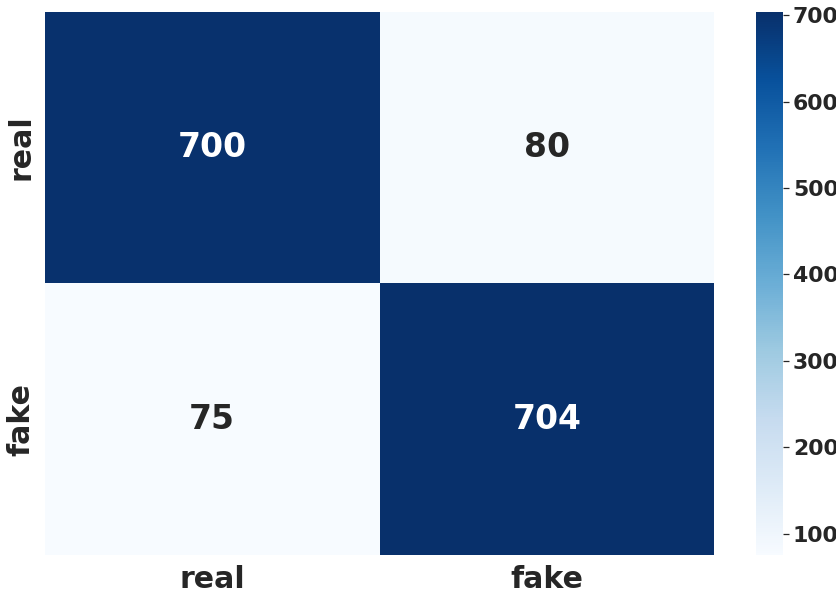

In [270]:
#naive bayes model
NBclassifer = MultinomialNB()
NBclassifer.fit(X_train, y_train)
y_pred = NBclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)


# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    

    
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)

    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\MNB_CM.png', bbox_inches="tight", dpi=100)

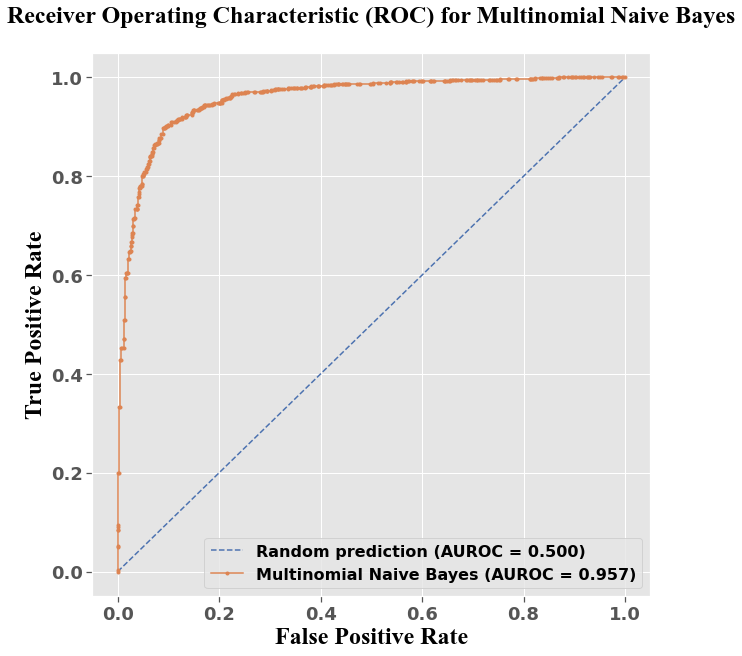

In [271]:
#Receiver Operating Characteristic (ROC) for Multinomial Naive Bayes
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
nb_probs = NBclassifer.predict_proba(X_test)

nb_probs = nb_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
nb_auc = roc_auc_score(y_test, nb_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)

#plt.rcParams['font.size'] = '18'
plt.rcParams['font.weight'] = 'bold'


plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(nb_fpr, nb_tpr, marker='.', label='Multinomial Naive Bayes (AUROC = %0.3f)' % nb_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Multinomial Naive Bayes\n', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16)  

plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\MNB_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()


In [272]:
from sklearn.svm import SVC

Test set accuracy 0.9178960872354073
              precision    recall  f1-score   support

        real       0.92      0.91      0.92       780
        fake       0.91      0.92      0.92       779

    accuracy                           0.92      1559
   macro avg       0.92      0.92      0.92      1559
weighted avg       0.92      0.92      0.92      1559



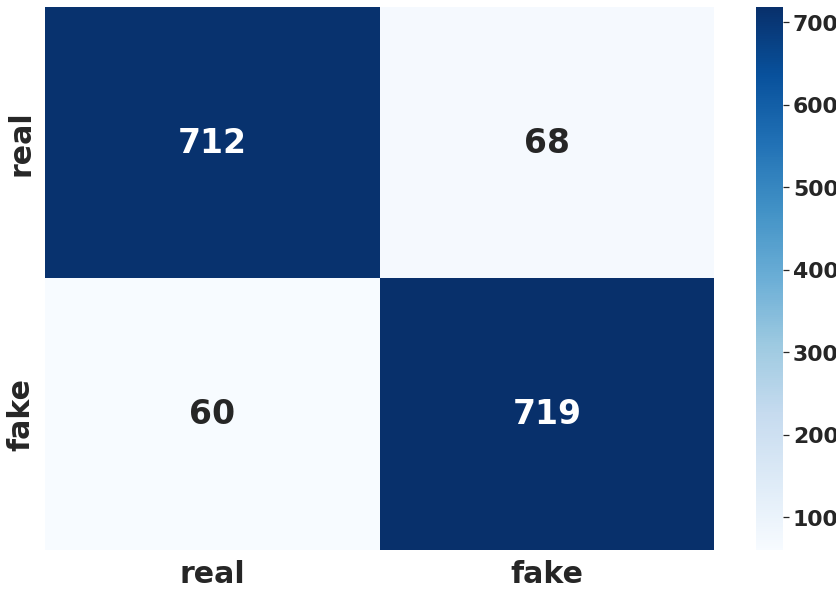

In [273]:
#SVM model
SVclassifer = SVC(kernel='linear', probability=True)
SVclassifer.fit(X_train, y_train)
y_pred = SVclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\SVM_cm.png', bbox_inches="tight", dpi=100)

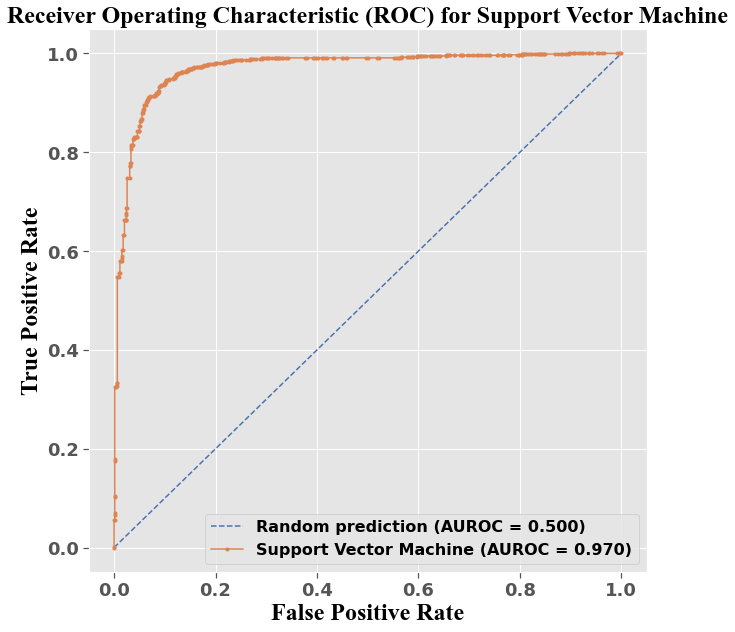

In [274]:
#Receiver Operating Characteristic (ROC) for SVM
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
sv_probs = SVclassifer.predict_proba(X_test)

sv_probs = sv_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
sv_auc = roc_auc_score(y_test, sv_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
sv_fpr, sv_tpr, _ = roc_curve(y_test, sv_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(sv_fpr, sv_tpr, marker='.', label='Support Vector Machine (AUROC = %0.3f)' % sv_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Support Vector Machine', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16) #
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\SVM_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()


In [275]:
from xgboost import XGBClassifier

Test set accuracy 0.9441949967928159
              precision    recall  f1-score   support

        real       0.92      0.97      0.95       780
        fake       0.97      0.92      0.94       779

    accuracy                           0.94      1559
   macro avg       0.95      0.94      0.94      1559
weighted avg       0.95      0.94      0.94      1559



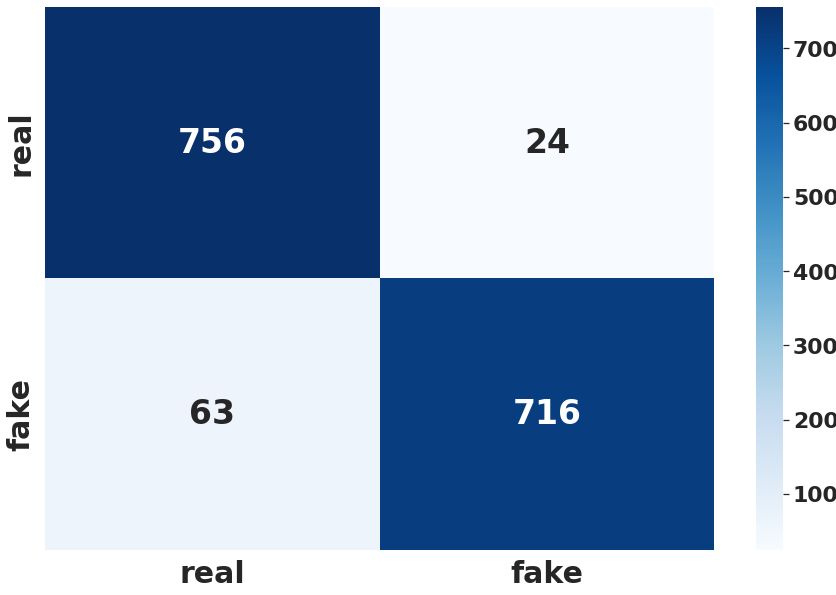

In [276]:
#XGBoost model
XGBclassifer = XGBClassifier()
XGBclassifer.fit(X_train, y_train)
y_pred = XGBclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\XGB_CM.png', bbox_inches="tight", dpi=100)
  

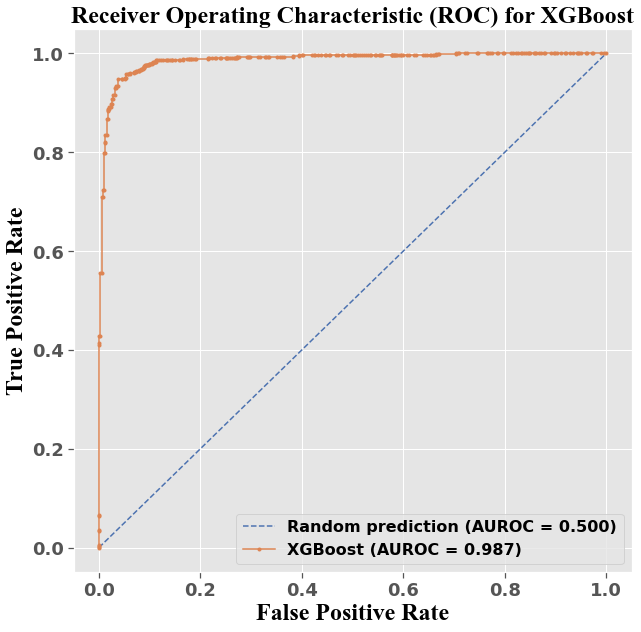

In [277]:
#Receiver Operating Characteristic (ROC) for XGBoost Classifier
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
xgb_probs = XGBclassifer.predict_proba(X_test)

xgb_probs = xgb_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(xgb_fpr, xgb_tpr, marker='.', label='XGBoost (AUROC = %0.3f)' % xgb_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for XGBoost', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16) 
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\XGB_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [278]:
from sklearn.ensemble import AdaBoostClassifier


Test set accuracy 0.8543938422065427
              precision    recall  f1-score   support

        real       0.85      0.85      0.85       780
        fake       0.85      0.85      0.85       779

    accuracy                           0.85      1559
   macro avg       0.85      0.85      0.85      1559
weighted avg       0.85      0.85      0.85      1559



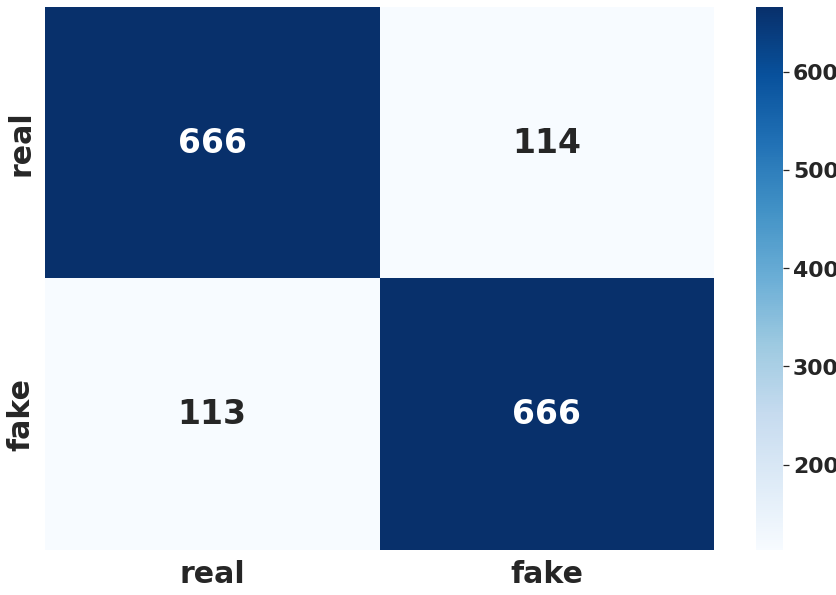

In [279]:
#Adaboost model
ADBclassifer = AdaBoostClassifier(n_estimators=60,
                         learning_rate=1)
ADBclassifer.fit(X_train, y_train)
y_pred = ADBclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\AdaB_CM.png', bbox_inches="tight", dpi=100)
  

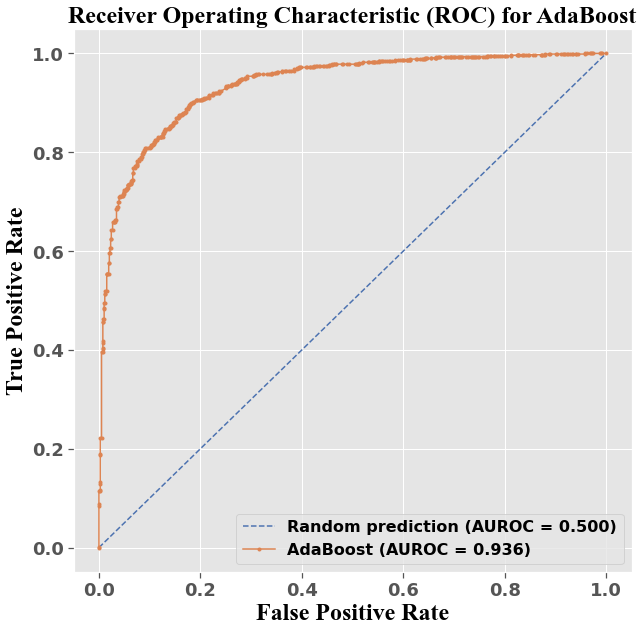

In [280]:
#Receiver Operating Characteristic (ROC) for AdaBoost Classifier
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
adb_probs = ADBclassifer.predict_proba(X_test)

adb_probs = adb_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
adb_auc = roc_auc_score(y_test, adb_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
adb_fpr, adb_tpr, _ = roc_curve(y_test, adb_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(adb_fpr, adb_tpr, marker='.', label='AdaBoost (AUROC = %0.3f)' % adb_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for AdaBoost', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16)
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\AdaB_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [281]:
from sklearn.tree import DecisionTreeClassifier

Test set accuracy 0.8736369467607441
              precision    recall  f1-score   support

        real       0.84      0.93      0.88       780
        fake       0.92      0.82      0.87       779

    accuracy                           0.87      1559
   macro avg       0.88      0.87      0.87      1559
weighted avg       0.88      0.87      0.87      1559



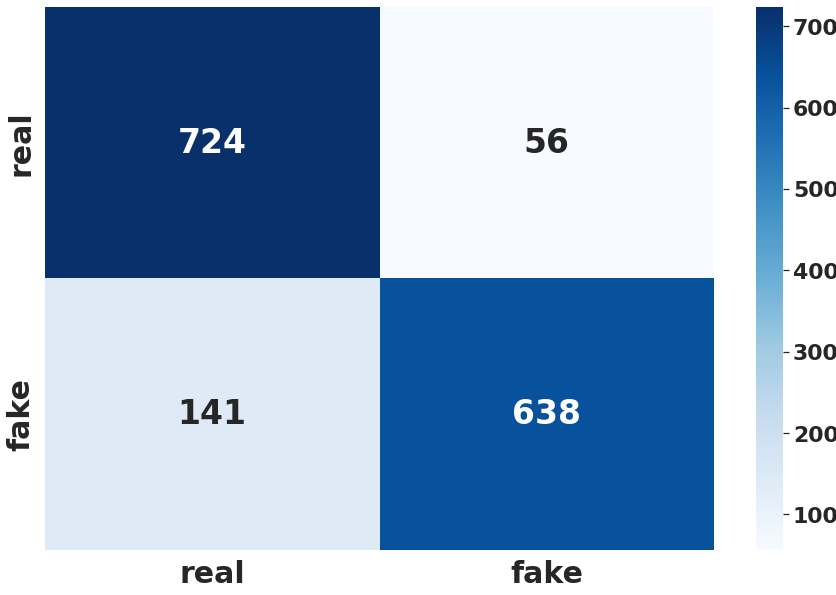

In [282]:
#decision tree
DTclassifer = DecisionTreeClassifier()
DTclassifer.fit(X_train, y_train)
y_pred = DTclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\DT_CM.png', bbox_inches="tight", dpi=100)
  


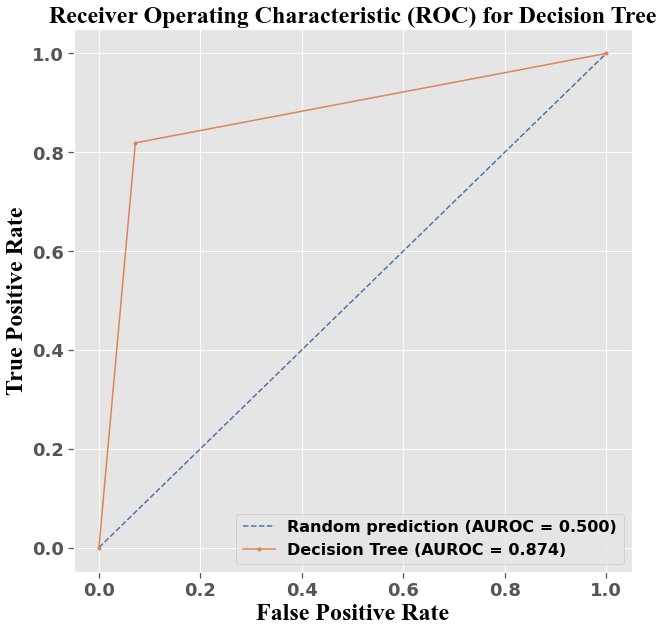

In [283]:
#Receiver Operating Characteristic (ROC) for Decision Tree Classifier
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
dt_probs = DTclassifer.predict_proba(X_test)

dt_probs = dt_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(dt_fpr, dt_tpr, marker='.', label='Decision Tree (AUROC = %0.3f)' % dt_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Decision Tree', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16) 
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\DT_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [284]:
from sklearn.ensemble import RandomForestClassifier

Test set accuracy 0.9390635022450289
              precision    recall  f1-score   support

        real       0.92      0.96      0.94       780
        fake       0.95      0.92      0.94       779

    accuracy                           0.94      1559
   macro avg       0.94      0.94      0.94      1559
weighted avg       0.94      0.94      0.94      1559



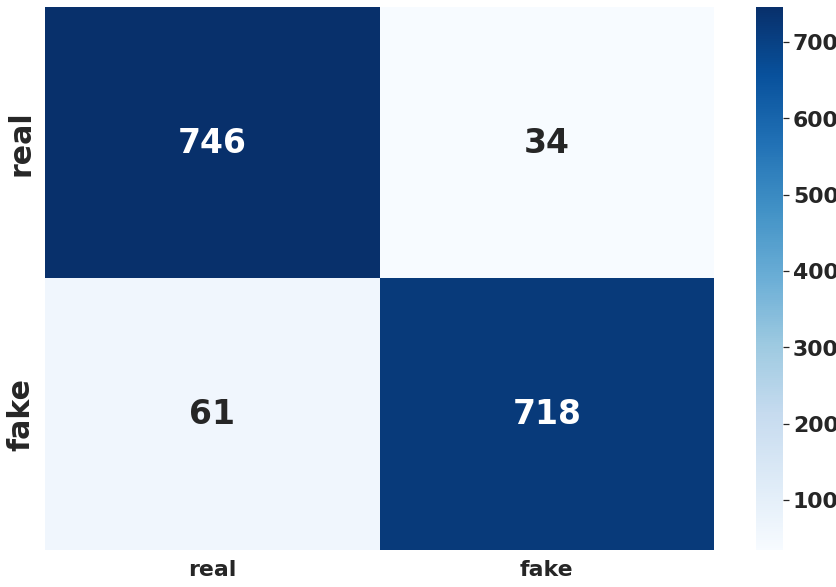

In [285]:
#Random forest
RFclassifer = RandomForestClassifier(n_estimators=100)
RFclassifer.fit(X_train, y_train)
y_pred = RFclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\RF_CM.png', bbox_inches="tight", dpi=100)
    

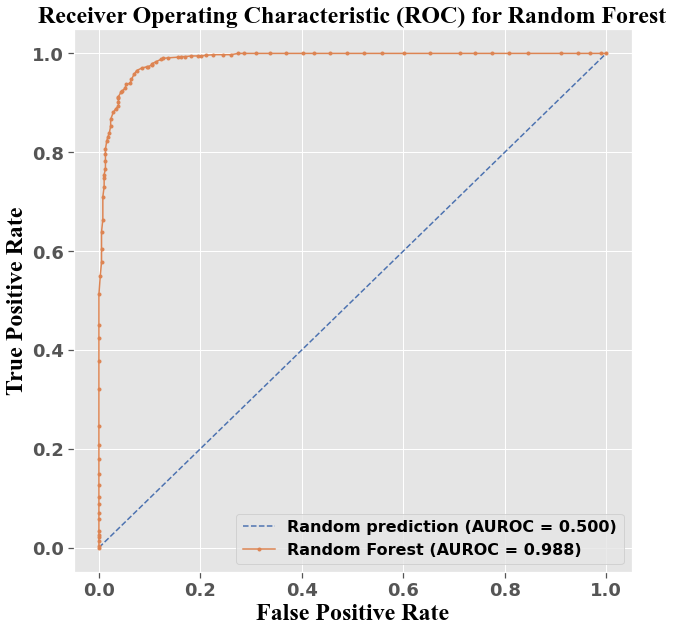

In [286]:
#Receiver Operating Characteristic (ROC) for Random Forest
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
rf_probs = RFclassifer.predict_proba(X_test)

rf_probs = rf_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest (AUROC = %0.3f)' % rf_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Random Forest', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16)
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\RF_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [287]:
from sklearn.linear_model import SGDClassifier

Test set accuracy 0.9352148813341886
              precision    recall  f1-score   support

        real       0.94      0.93      0.94       780
        fake       0.93      0.94      0.94       779

    accuracy                           0.94      1559
   macro avg       0.94      0.94      0.94      1559
weighted avg       0.94      0.94      0.94      1559



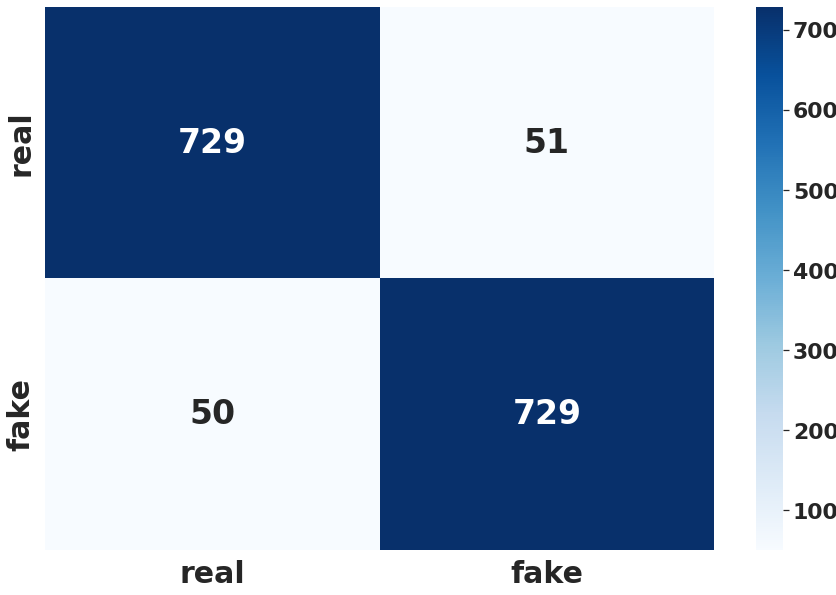

In [288]:
#model stochastic gradient discent model
SGDclassifer = SGDClassifier(loss='hinge')
SGDclassifer.fit(X_train, y_train)
y_pred = SGDclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #


cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\SGD_CM.png', bbox_inches="tight", dpi=100)
    

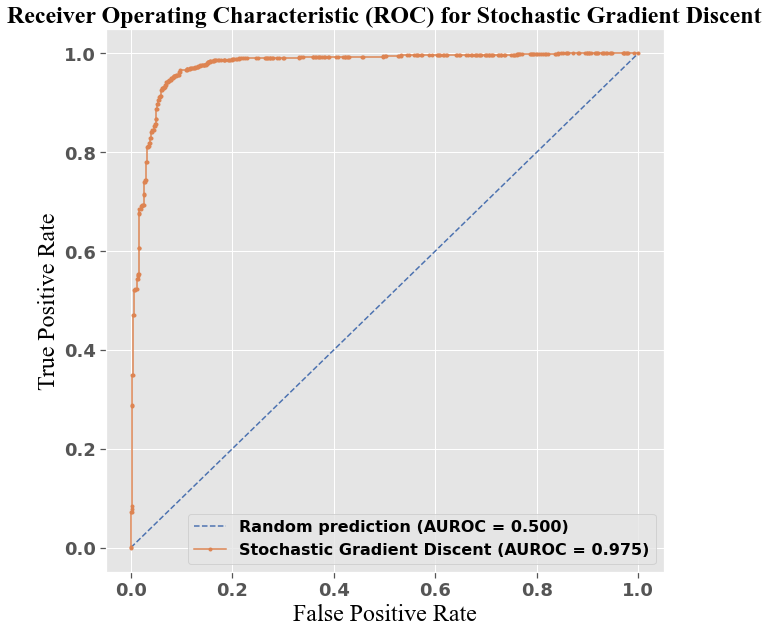

In [289]:
#Receiver Operating Characteristic (ROC) for stochastic gradient discent
plt.figure(figsize=(10,10))

from sklearn.calibration import CalibratedClassifierCV
lr = SGDClassifier(loss='hinge',class_weight='balanced')
clf =lr.fit(X_train, y_train)
calibrator = CalibratedClassifierCV(clf, cv='prefit')
model=calibrator.fit(X_train, y_train)

r_probs = [0 for _ in range(len(y_test))]
sgd_probs = model.predict_proba(X_test)

sgd_probs = sgd_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
sgd_auc = roc_auc_score(y_test, sgd_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
sgd_fpr, sgd_tpr, _ = roc_curve(y_test, sgd_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(sgd_fpr, sgd_tpr, marker='.', label='Stochastic Gradient Discent (AUROC = %0.3f)' % sgd_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Stochastic Gradient Discent', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16)
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\SGD_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [290]:
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

Test set accuracy 0.8082103912764592
              precision    recall  f1-score   support

        real       0.83      0.78      0.80       780
        fake       0.79      0.84      0.81       779

    accuracy                           0.81      1559
   macro avg       0.81      0.81      0.81      1559
weighted avg       0.81      0.81      0.81      1559



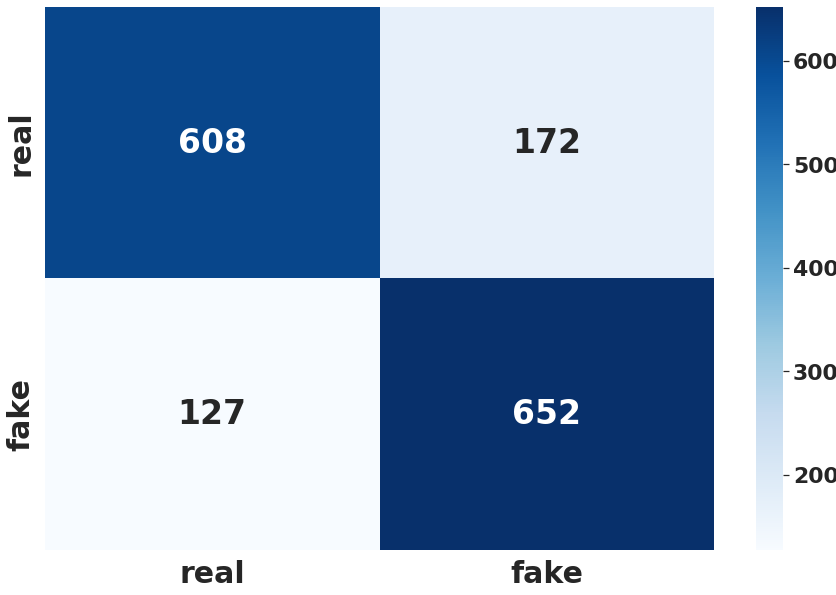

In [291]:
#Knn model
KNNclassifer = KNeighborsClassifier(n_neighbors=3)
KNNclassifer.fit(X_train, y_train)
y_pred = KNNclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\KNN_CM.png', bbox_inches="tight", dpi=100)
    

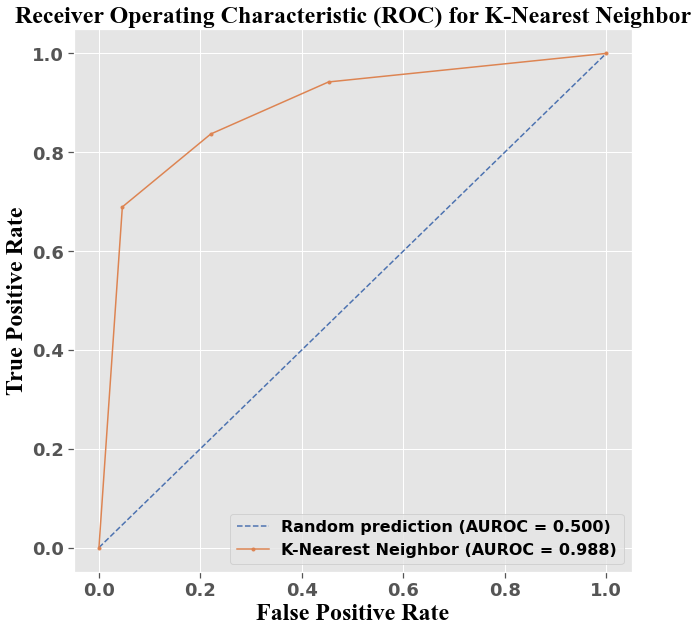

In [292]:
#Receiver Operating Characteristic (ROC) for K-Nearest Neighbor
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
knn_probs = KNNclassifer.predict_proba(X_test)

knn_probs = knn_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
knn_auc = roc_auc_score(y_test, knn_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(knn_fpr, knn_tpr, marker='.', label='K-Nearest Neighbor (AUROC = %0.3f)' % rf_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for K-Nearest Neighbor', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16) 
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\KNN_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [293]:
from sklearn.linear_model import LogisticRegression

Test set accuracy 0.9076330981398332
              precision    recall  f1-score   support

        real       0.91      0.91      0.91       780
        fake       0.91      0.91      0.91       779

    accuracy                           0.91      1559
   macro avg       0.91      0.91      0.91      1559
weighted avg       0.91      0.91      0.91      1559



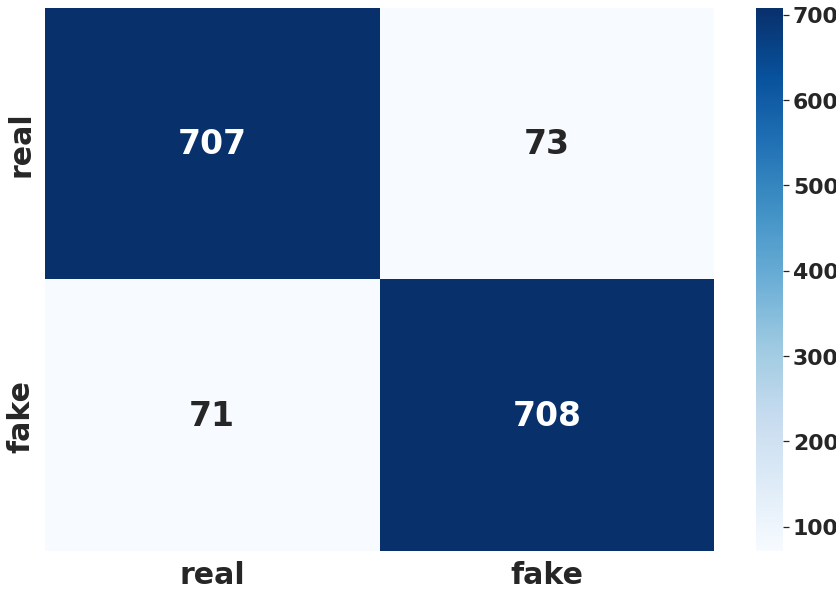

In [294]:
#logistic regression model
LRclassifer = LogisticRegression()
LRclassifer.fit(X_train, y_train)
y_pred = LRclassifer.predict(X_test)
print('Test set accuracy %s' % accuracy_score(y_test, y_pred))
cr = classification_report(y_test, y_pred, target_names=target_names)
print(cr)

# ------------------------------------------------------------------------------ #

cm = confusion_matrix(y_test, y_pred)
#cm = (cm.T / cm.astype(float).sum(axis=1)).T

df_cm = pd.DataFrame(cm, range(len(target_names)), range(len(target_names)))
with sn.axes_style("white"):
    plt.figure(figsize = (15,10))
    ax = sn.heatmap(df_cm, annot=True, xticklabels=target_names, yticklabels=target_names, cmap='Blues', annot_kws={
                'fontsize': 33,
                'fontweight': 'bold'
            }, fmt='')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=30, fontweight='bold')
    plt.yticks(fontsize=30, fontweight='bold')
    sn.set(font_scale=2)
    
    fig = ax.get_figure()
    plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\LR_CM.png', bbox_inches="tight", dpi=100)
    

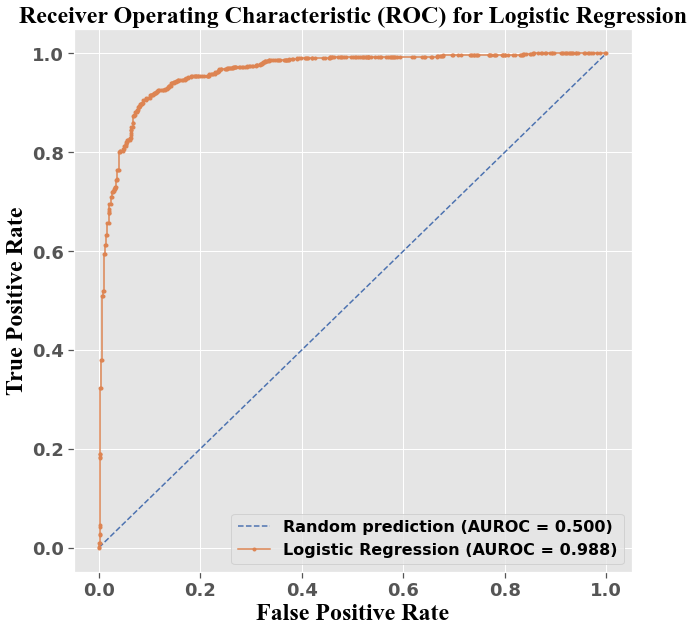

In [295]:
#Receiver Operating Characteristic (ROC) for logistic Regression
plt.figure(figsize=(10,10))
r_probs = [0 for _ in range(len(y_test))]
lr_probs = LRclassifer.predict_proba(X_test)

lr_probs = lr_probs[:, 1]

r_auc = roc_auc_score(y_test, r_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

r_fpr, r_tpr, _ = roc_curve(y_test, r_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

plt.rcParams['font.weight'] = 'bold'
plt.tick_params(labelsize=18)

plt.plot(r_fpr, r_tpr, linestyle='--', label='Random prediction (AUROC = %0.3f)' % r_auc)
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic Regression (AUROC = %0.3f)' % rf_auc)

# Title
plt.title('Receiver Operating Characteristic (ROC) for Logistic Regression', fontweight='bold', fontfamily='times new roman')
# Axis labels
plt.xlabel('False Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
plt.ylabel('True Positive Rate', fontweight='bold', fontfamily='times new roman', color='black')
# Show legend
plt.legend(loc="lower right", fontsize=16)
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\LR_ROC.png', bbox_inches="tight", dpi=100)
# Show plot
plt.show()

In [296]:
#save model 
import joblib 
joblib.dump(XGBclassifer, 'News.pkl')

['News.pkl']

In [297]:
model = joblib.load('News.pkl')

In [298]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import average_precision_score,roc_auc_score, roc_curve, precision_recall_curve

In [299]:
def ml_models_defination(): 
     
    NBclassifer = MultinomialNB()
    SVclassifer = SVC(kernel='linear', probability=True)
    XGBclassifer = XGBClassifier()
    ADBclassifer = AdaBoostClassifier(n_estimators=60,learning_rate=1)
    DTclassifer = DecisionTreeClassifier()
    RFclassifer = RandomForestClassifier(n_estimators=100)
    SGDclassifer = SGDClassifier(loss='hinge')
    KNNclassifer = KNeighborsClassifier(n_neighbors=3)
    LRclassifer = LogisticRegression()
    

    model_names = ['Multinomial Naive Bayes','Support Vector Machine','XGBoost','Adaptive Boosting','Decision Tree','Random Forest','Simple Gradient Descent','K-Nearest Neighbor', 'Logistic Regression']
  
    # Create list of models
    ml_models = [NBclassifer, SVclassifer, XGBclassifer, ADBclassifer, DTclassifer, RFclassifer, SGDclassifer, KNNclassifer, LRclassifer]
    #ml_models = [lr_model]
    return ml_models,model_names 

In [300]:
def model_performace(model,X_train,X_test,y_train,y_test):
   
    my_dict = {}
    model.fit(X_train,y_train)
    # Prediction
    pred_y = model.predict(X_test)
    my_dict['Accuracy'] = round(accuracy_score(y_test, pred_y),6) 
    my_dict['Precision'] = round(precision_score(y_test, pred_y),6) 
    my_dict['Recall'] = round(recall_score(y_test, pred_y),6)
    my_dict['F1 Score'] = round(f1_score(y_test, pred_y),6) 
    
    return my_dict  

In [301]:
def performance_table(performance_dict):
    acc_list = []
    pr_list = []
    re_list = []
    f1_list = []
    for i in performance_dict.keys():
        acc_list.append(performance_dict[i]['Accuracy'])
        pr_list.append(performance_dict[i]['Precision'])
        re_list.append(performance_dict[i]['Recall'])
        f1_list.append(performance_dict[i]['F1 Score'])

    # Create a dataframe
    model_names = ['MNB','SVM','XGBoost','AdaBoost','DT','RF','SGD','KNN', 'LR']
    performance_df = pd.DataFrame({'Accuracy':acc_list,'Precision':pr_list,
                                   'Recall':re_list,'F1 Score':f1_list,
                                   'Model Name':model_names })
    return performance_df

In [302]:
X_train, X_test, y_train, y_test = train_test_split(train_tfidf, df['Text_label'],stratify=df['Text_label'], test_size=0.3, random_state=42)

Y_pre = df['label']
target_names = list(set(Y_pre))

ml_models,model_names = ml_models_defination()
# call model accuracy function and save the metrices into a dictionary
accuracy = {f'{model_names[j]}':model_performace(model,X_train,X_test,y_train,y_test) for j,model in enumerate(ml_models)}
#Save the performance parameter into json file

In [303]:
table = performance_table(accuracy)
print(f"\n========== Performace Table for all models:========\n",table)
print(f"\n")
    
print(f"Highest Accuracy achieved by {table['Model Name'][table.Accuracy.idxmax(axis = 0)]} at = {max(table.Accuracy)}")
print(f"Highest F1-Score achieved by {table['Model Name'][table['F1 Score'].idxmax(axis = 0)]} at = {max(table['F1 Score'] )}")
print(f"Highest Precision Score achieved by {table['Model Name'][table['Precision'].idxmax(axis = 0)]} at = {max(table['Precision'] )}")
print(f"Highest Recall Score achieved by {table['Model Name'][table['Recall'].idxmax(axis = 0)]} at = {max(table['Recall'] )}")


========== Performace Table for all models:========
    Accuracy  Precision    Recall  F1 Score Model Name
0  0.900577   0.897959  0.903723  0.900832        MNB
1  0.917896   0.913596  0.922978  0.918263        SVM
2  0.944195   0.967568  0.919127  0.942725    XGBoost
3  0.854394   0.853846  0.854942  0.854394   AdaBoost
4  0.866581   0.906117  0.817715  0.859649         DT
5  0.935215   0.947230  0.921694  0.934288         RF
6  0.932649   0.932051  0.933248  0.932649        SGD
7  0.808210   0.791262  0.836970  0.813475        KNN
8  0.907633   0.906530  0.908858  0.907692         LR


Highest Accuracy achieved by XGBoost at = 0.944195
Highest F1-Score achieved by XGBoost at = 0.942725
Highest Precision Score achieved by XGBoost at = 0.967568
Highest Recall Score achieved by SGD at = 0.933248


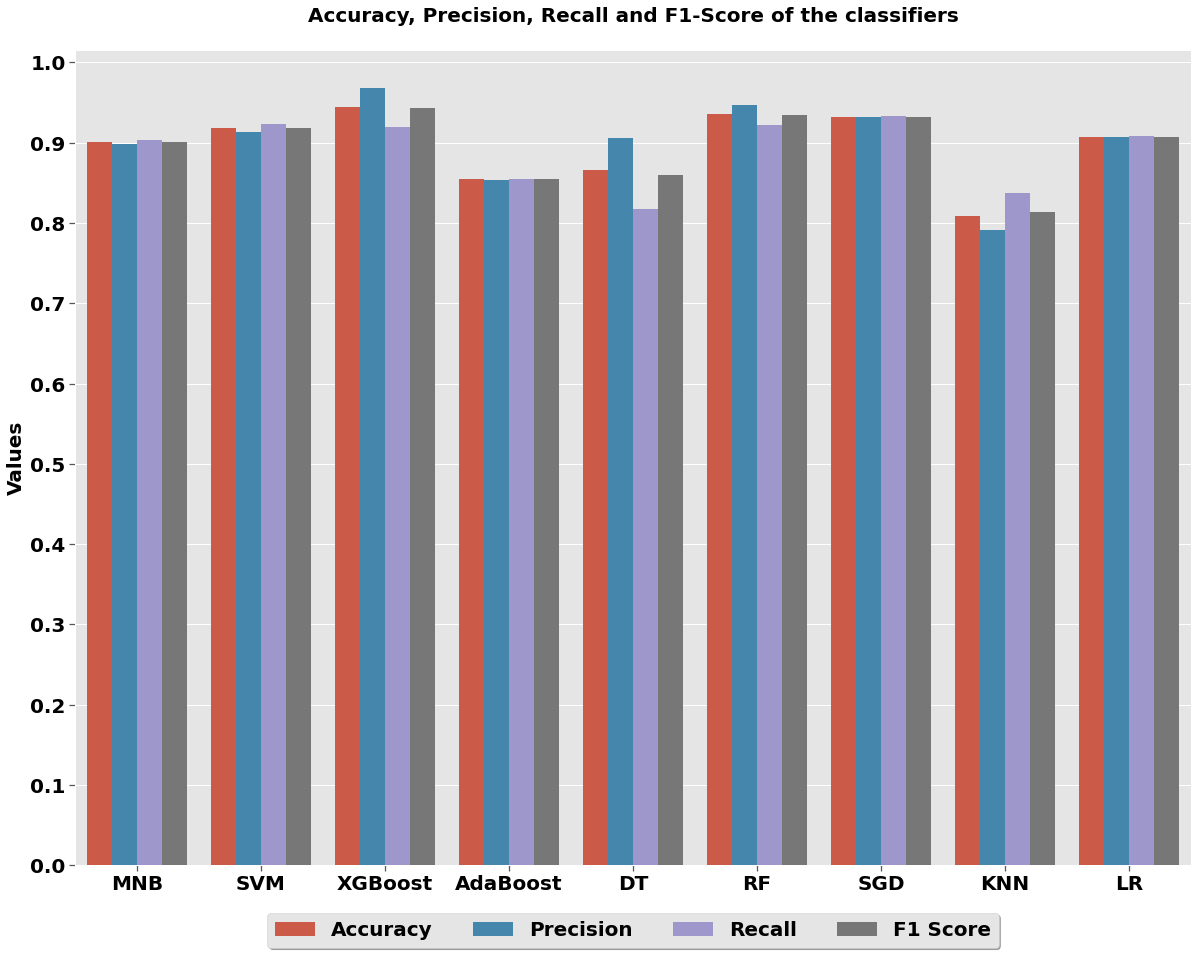

In [304]:
import numpy as np
from matplotlib import style


plt.style.use('ggplot')
table = performance_table(accuracy)
df = pd.melt(table, id_vars="Model Name", var_name="Category", value_name="Values")
plt.figure(figsize=(20,15))

ax = plt.subplot()
sns.barplot(data=df,x='Model Name', y='Values' ,hue='Category')
ax.set_xlabel('')
ax.set_ylabel('Values', color='black', fontsize=20, fontweight='bold')
ax.set_title(f'Accuracy, Precision, Recall and F1-Score of the classifiers\n', fontsize=20, fontweight='bold')
plt.yticks(np.arange(0, 1.1, 0.1))
ax.xaxis.set_ticklabels(table['Model Name'], fontsize=20, color='black', fontweight='bold');
leg=plt.legend(loc='center', bbox_to_anchor=(0.5, -0.08), shadow=True, ncol=4, fontsize=20, frameon=True)
for text in leg.get_texts():
 text.set_color("black")
plt.yticks(fontsize=20, color='black', fontweight='bold')
plt.savefig('F:\Bangla Fake News Detection Using Machine Learning and Inferancing with FastApi\outputs\Performance Histogram.png', bbox_inches="tight", dpi=100)